## Importing Modules

In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,Literal
from IPython.display import Image
from dotenv import load_dotenv,find_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import os
import operator

load_dotenv(find_dotenv())

True

## Quadratic Equation

In [12]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result :str

In [13]:
def show_equation(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    equation = f"{a}x^2 + {b}x + {c} = 0"
   
    return {"equation":equation}

def compute_discriminant(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant":discriminant}

def real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = state['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    result = f"Real roots: {root1}, {root2}"
    return {"result":result}

def repet_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    root = -b / (2*a)
    result = f"Repeated root: {root}"
    return {"result":result}

def no_real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = state['discriminant']
    real_part = -b / (2*a)
    imaginary_part = (abs(discriminant)**0.5) / (2*a)
    result = f"Complex roots: {real_part} + {imaginary_part}i, {real_part} - {imaginary_part}i"
    return {"result":result}

def check_condition(state:QuadState) -> Literal["real_roots","repet_roots","no_real_roots"]:
    discriminant = state['discriminant']
    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "repet_roots"
    else:
        return "no_real_roots"


In [14]:
graph = StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("compute_discriminant",compute_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("no_real_roots",no_real_roots)
graph.add_node("repet_roots",repet_roots)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","compute_discriminant")
graph.add_conditional_edges("compute_discriminant",check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("no_real_roots",END)
graph.add_edge("repet_roots",END)

workflow = graph.compile()

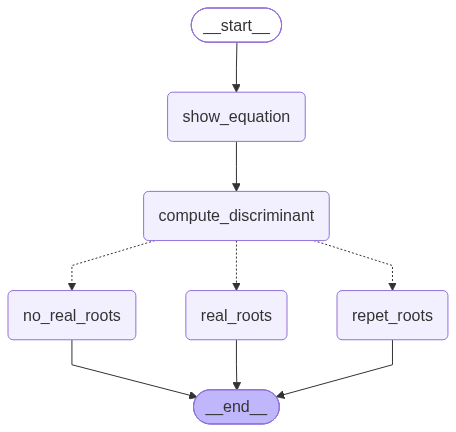

In [15]:
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
inital_state = {"a":1,"b":2,"c":1}
workflow.invoke(inital_state)

{'a': 1,
 'b': 2,
 'c': 1,
 'equation': '1x^2 + 2x + 1 = 0',
 'discriminant': 0,
 'result': 'Repeated root: -1.0'}

In [17]:
inital_state = {"a":2,"b":-4,"c":6}
workflow.invoke(inital_state)

{'a': 2,
 'b': -4,
 'c': 6,
 'equation': '2x^2 + -4x + 6 = 0',
 'discriminant': -32,
 'result': 'Complex roots: 1.0 + 1.4142135623730951i, 1.0 - 1.4142135623730951i'}

## LLM BASED REVIEW HANDLING

In [18]:

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

print(GROQ_API_KEY[:10])  # Just to verify it's loaded

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

gsk_3oeoml


In [20]:
class SentimentSchema(BaseModel):
    
    sentiment: Literal["positive", "negative"] =  Field(description="The sentiment of the text.")

In [26]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [27]:
structured_model = llm.with_structured_output(SentimentSchema)
structured_model_diagnosis = llm.with_structured_output(DiagnosisSchema)

In [23]:
## test
prompt = "What is sentiment of the text: 'I love this product!'"
structured_model.invoke(prompt)

SentimentSchema(sentiment='positive')

In [24]:
class ReviewState(TypedDict):
    review_text: str
    sentiment: Literal["positive", "negative"]
    diagnosis : dict
    response : str

In [33]:
def find_sentiment(state: ReviewState) -> ReviewState:
    review_text = state['review_text']
    prompt = f"What is the sentiment of the text: '{review_text}'"
    sentiment_result = structured_model.invoke(prompt)
     
    return {"sentiment": sentiment_result.sentiment }


def check_sentiment(state: ReviewState) -> Literal["positive_response","run_diagnosis"]:
    
    if state['sentiment'] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""
Write a warm, professional thank you response to the following positive customer review:

Review:
"{state['review_text']}"
"""

    response = llm.invoke(prompt).content

    return {"response": response}


def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review_text']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model_diagnosis.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = llm.invoke(prompt).content

    return {'response': response}
    

In [35]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)


graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)

workflow_2 = graph.compile()

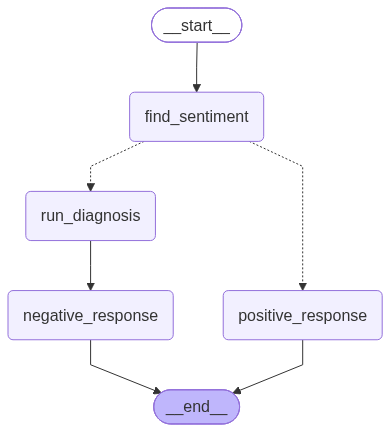

In [30]:
Image(workflow_2.get_graph().draw_mermaid_png())

In [31]:
intial_state = {"review_text":"I love this product!"}
workflow_2.invoke(intial_state)

{'review_text': 'I love this product!',
 'sentiment': 'positive',
 'response': 'Here is a warm, professional thank you response:\n\n"Dear valued customer, \n\nWe are thrilled to hear that you love our product! We appreciate you taking the time to share your positive experience with us. Your satisfaction is our top priority, and we\'re grateful for customers like you who make our work worthwhile. Thank you again for your kind words and for choosing our product. We\'re honored to have you as a customer and look forward to serving you in the future.\n\nBest regards, [Your Company Name]"'}

In [36]:
intial_state = {"review_text":"Useless Product fuck off"}
workflow_2.invoke(intial_state)

{'review_text': 'Useless Product fuck off',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other', 'tone': 'angry', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing an issue that's causing you frustration. I can imagine how upsetting it must be, and I'm here to help you resolve it as quickly as possible.\n\nI want to start by acknowledging your concern and letting you know that I'm taking your issue very seriously. I understand that you've marked the urgency as high, and I'll do my best to provide a prompt and effective solution.\n\nCan you please provide me with more details about the issue you're facing? The more information you can share, the better I'll be able to understand the problem and work towards a resolution. I'm committed to listening to your concerns and working with you to find a solution that meets your needs.\n\nIf there's anything I can do to make things right or provide a temporary workaround, please let me know. Your satisfact